# Hi , I am just learning , if there are any suggestions or topics that I can learn to improve please let me know

In [1]:
# IMPORTING LIBRARIES
import pandas as pd
import numpy as np
import tensorflow as tf 
import os
import zipfile
from tensorflow import keras
from keras import layers

2026-01-19 10:12:23.866156: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768817544.131834      19 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768817544.220106      19 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768817544.840575      19 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768817544.840656      19 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768817544.840660      19 computation_placer.cc:177] computation placer alr

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vbookshelf/rice-leaf-diseases")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/rice-leaf-diseases


In [3]:
data_dir='/kaggle/input/rice-leaf-diseases/rice_leaf_diseases/'
disease_names=[
    folder for folder in os.listdir(data_dir)
    if os.path.isdir(os.path.join(data_dir,folder))
]
print('Disease names:',disease_names)

Disease names: ['Brown spot', 'Bacterial leaf blight', 'Leaf smut']


In [4]:
for disease in disease_names:
    folder_path = os.path.join(data_dir, disease)
    num_images = len([
        f for f in os.listdir(folder_path)
        if f.lower().endswith(('.jpg', '.png', '.jpeg'))
    ])
    print(f"{disease}: {num_images} images")


Brown spot: 40 images
Bacterial leaf blight: 40 images
Leaf smut: 40 images


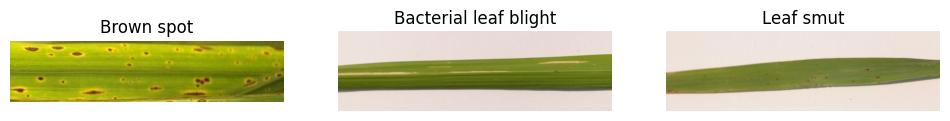

In [5]:
import matplotlib.pyplot as plt
from PIL import Image
import random

plt.figure(figsize=(12,4))

for i, disease in enumerate(disease_names):
    folder_path = os.path.join(data_dir, disease)
    images = [
        img for img in os.listdir(folder_path)
        if img.lower().endswith(('.jpg', '.png', '.jpeg'))
    ]
    
    img_path = os.path.join(folder_path, random.choice(images))
    img = Image.open(img_path)

    plt.subplot(1, len(disease_names), i+1)
    plt.imshow(img)
    plt.title(disease)
    plt.axis("off")

plt.show()


In [6]:
###  splitting data 
train_ds=tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    image_size=(224,224),
    subset='training',validation_split=0.1,
    label_mode='categorical',batch_size=4
    ,seed=42,shuffle=True
)
validation_ds=tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,image_size=(224,224),subset='validation',
    validation_split=0.1,label_mode='categorical',batch_size=4,seed=42,shuffle=True
)

Found 120 files belonging to 3 classes.
Using 108 files for training.
Found 120 files belonging to 3 classes.
Using 12 files for validation.


2026-01-19 10:12:46.630673: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [7]:
early_stop=tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5, restore_best_weights=True
)
lr_schedule=tf.keras.callbacks.ReduceLROnPlateau(
    monitor= 'val_loss', factor=0.3,patience=3,min_lr=1e-6,verbose=1
)

data_augmentation=tf.keras.Sequential([
    layers.RandomFlip('Horizontal'),
    layers.RandomRotation(0.20),
    layers.RandomZoom(0.3)
])

In [8]:
base_model=tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,weights='imagenet'
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [9]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

base_model.trainable=False

inputs=tf.keras.Input(shape=(224,224,3))
x = preprocess_input(inputs)

x=data_augmentation(x)
x=base_model(x,training = False)
x=tf.keras.layers.GlobalAveragePooling2D()(x)
x=tf.keras.layers.Dense(64,activation='relu')(x)
x=tf.keras.layers.Dropout(0.4)(x)

output=tf.keras.layers.Dense(3,activation='softmax')(x)
tf_model=tf.keras.Model(inputs,output)

In [10]:
tf_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,163 (8.93 MB)

 Trainable params: 82,179 (321.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [11]:
tf_model.compile(optimizer = tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4),loss='categorical_crossentropy',metrics=['accuracy'])

In [12]:
history2=tf_model.fit(train_ds,validation_data=validation_ds,epochs=30,verbose =1,callbacks=[early_stop,lr_schedule])

Epoch 1/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 13s 241ms/step - accuracy: 0.3826 - loss: 1.4899 - val_accuracy: 0.5833 - val_loss: 0.8012 - learning_rate: 0.0010
Epoch 2/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 166ms/step - accuracy: 0.7934 - loss: 0.5081 - val_accuracy: 0.6667 - val_loss: 0.6366 - learning_rate: 0.0010
Epoch 3/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 149ms/step - accuracy: 0.7608 - loss: 0.4875 - val_accuracy: 0.7500 - val_loss: 0.4738 - learning_rate: 0.0010
Epoch 4/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 145ms/step - accuracy: 0.8877 - loss: 0.2814 - val_accuracy: 0.6667 - val_loss: 0.5013 - learning_rate: 0.0010
Epoch 5/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 144ms/step - accuracy: 0.9448 - loss: 0.1789 - val_accuracy: 0.7500 - val_loss: 0.4350 - learning_rate: 0.0010
Epoch 6/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 141ms/step - accuracy: 0.9457 - loss: 0.1756 - val_accuracy: 0.8333 - val_loss: 0.4161 - learning_rate: 0.0010
Epoch 7/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 144ms/step - accuracy: 0.9253 - loss: 0.1931 -

In [13]:
val_loss, val_accuracy = tf_model.evaluate(validation_ds)
print(f"Validation Accuracy: {val_accuracy*100:.2f}%")
print(f"Validation Loss: {val_loss:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 1.0000 - loss: 0.2385
Validation Accuracy: 100.00%
Validation Loss: 0.2303


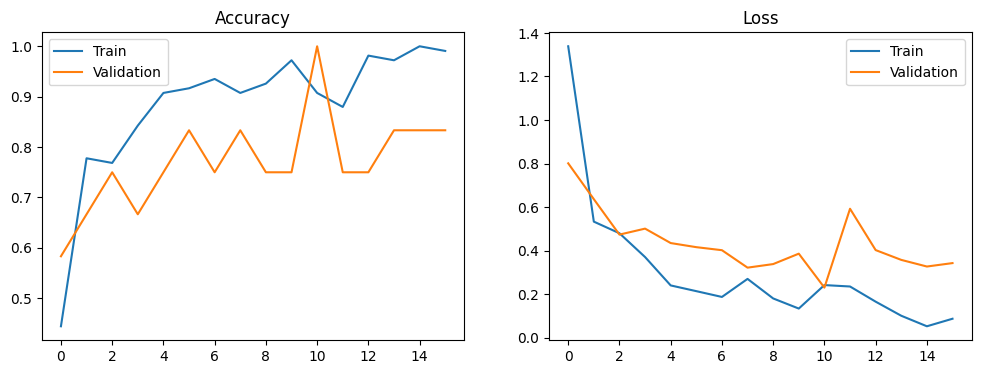

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history2.history['accuracy'], label='Train')
plt.plot(history2.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history2.history['loss'], label='Train')
plt.plot(history2.history['val_loss'], label='Validation')
plt.title('Loss')
plt.legend()

plt.show()